## Part 1 — Threshold Optimization

- Using predict_proba
- Testing Different Thresholds
- Comparing Recall / Precision / F1
- Choosing the Best Threshold from a Business Perspective

## Research Questions

1) Why is the default classification threshold (0.5) not always the best choice?
2) What trade-off exists between Precision and Recall when changing the classification threshold?
3) Suppose lowering the threshold increases Recall but decreases Precision. When would this be a good business decision?
4) After selecting the final threshold, why should the same threshold always be used in production?
5) Why is it important to save the entire preprocessing pipeline together with the trained model instead of saving only the classifier?
6) Imagine your churn prediction model will be used every day by a customer retention team. How would you justify your final threshold selection from both:

- Engineering perspective
- Business perspective

---

- 1-The default threshold may not provide the best balance between Precision and Recall for a specific business problem. Adjusting the threshold allows us to optimize the model according to business objectives and error costs.

- 2-Lowering the threshold usually increases Recall but decreases Precision, while raising the threshold has the opposite effect.

- 3-Lowering the threshold is a good choice when missing true positive cases is more costly than generating false alarms, such as in customer churn prediction.

- 4-The same threshold should be used in production to ensure consistent predictions and maintain the validated model performance.

- 5-The selected threshold should remain consistent in production because it was chosen during model evaluation to achieve the desired business trade-off. Changing it without re-evaluation may significantly alter Precision and Recall.

- 6-1-The threshold should be selected based on evaluation metrics to achieve the best balance between Precision and Recall.

- 6-2-The threshold should maximize business value by identifying as many at-risk customers as possible while keeping unnecessary interventions at an acceptable level.

In [72]:
# Imports 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, roc_curve, roc_auc_score, average_precision_score
import joblib

In [3]:
# Load Clean Dataset
df = pd.read_csv('../data/processed/customer_churn_clean.csv')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Feature & Target Separation
X = df.drop(columns='Churn')
y = df['Churn'].map({"No": 0, "Yes": 1})

In [5]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.3, random_state=42, stratify=y)

In [6]:
# Load Model
model = joblib.load("../models/logistic_regression_pipeline.joblib")

In [7]:
# Prediction
pred = model.predict(X_test)

proba = model.predict_proba(X_test)[:, 1]

In [30]:
# Creating different thresholds for experiments
thresholds = np.linspace(0.2,0.8,13)
predictions = []
for threshold in thresholds:
    prediction = proba >= threshold
    predictions.append(
        {
            'Threshold': threshold,
            'Accuracy': accuracy_score(y_test, prediction),
            'Precision': precision_score(y_test, prediction),
            'Recall': recall_score(y_test, prediction),
            'F1': f1_score(y_test, prediction)
        }
    )

In [33]:
# Building a probability dataframe
proba_df = pd.DataFrame(predictions).sort_values(by='Recall', ascending=False)

In [34]:
proba_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.20,0.695261,0.460501,0.852050,0.597874
1,0.25,0.729858,0.495114,0.812834,0.615385
2,0.30,0.754502,0.526380,0.764706,0.623547
3,0.35,0.769668,0.550882,0.723708,0.625578
4,0.40,0.787678,0.585997,0.686275,0.632184
5,0.45,0.797156,0.614853,0.634581,0.624561
6,0.50,0.805687,0.655670,0.566845,0.608031
7,0.55,0.800948,0.676692,0.481283,0.562500
8,0.60,0.787678,0.678233,0.383244,0.489749
9,0.65,0.775355,0.696833,0.274510,0.393862


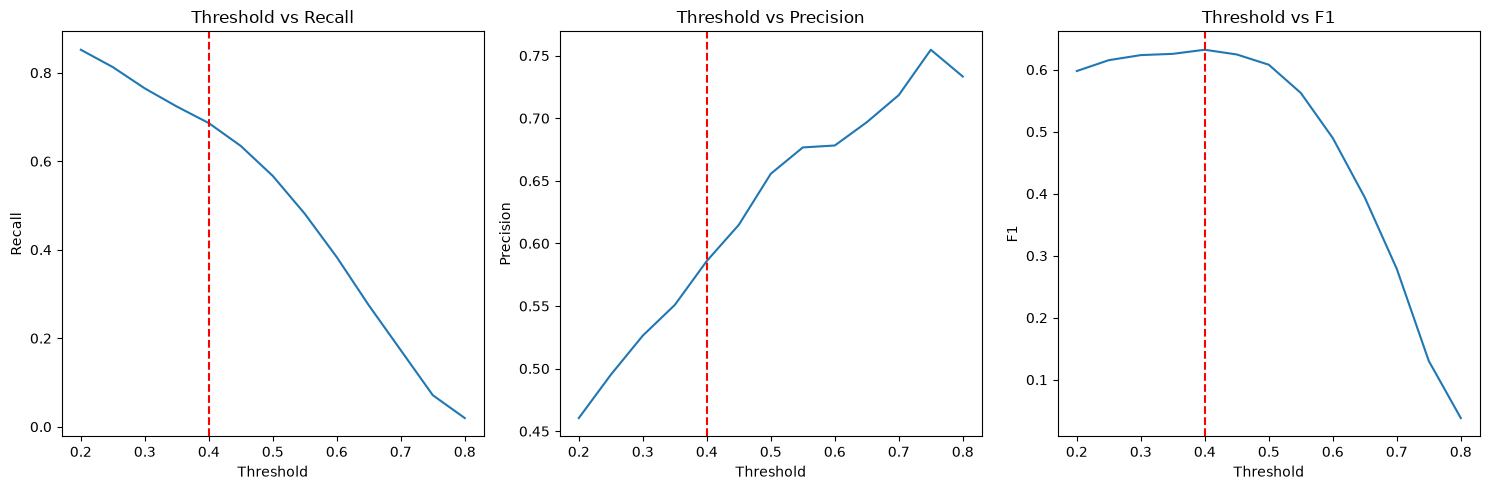

In [78]:
# Visualization
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(proba_df['Threshold'], proba_df['Recall'])
ax[0].set_title('Threshold vs Recall')
ax[0].set_xlabel('Threshold')
ax[0].set_ylabel('Recall')
ax[0].axvline(0.4, color="red", linestyle="--")
ax[1].plot(proba_df['Threshold'], proba_df['Precision'])
ax[1].set_title('Threshold vs Precision')
ax[1].set_xlabel('Threshold')
ax[1].set_ylabel('Precision')
ax[1].axvline(0.4, color="red", linestyle="--")
ax[2].plot(proba_df['Threshold'], proba_df['F1'])
ax[2].set_title('Threshold vs F1')
ax[2].set_xlabel('Threshold')
ax[2].set_ylabel('F1')
ax[2].axvline(0.4, color="red", linestyle="--")
plt.tight_layout()
plt.savefig("../figures/Sprint12/threshold_optimization.png", dpi=300)
plt.show()

In [48]:
# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, proba)

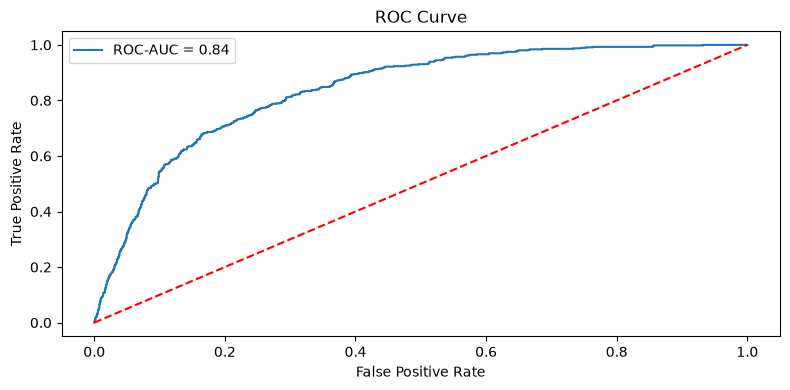

In [68]:
plt.figure(figsize=(8, 4))
plt.plot(fpr, tpr, label=f'ROC-AUC = {np.round(roc_auc_score(y_test, proba), 2)}')
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig("../figures/Sprint12/roc_curve.png", dpi=300)
plt.show()

In [66]:
# PR Curve
precision, recall, threshold_prc = precision_recall_curve(y_test, proba)

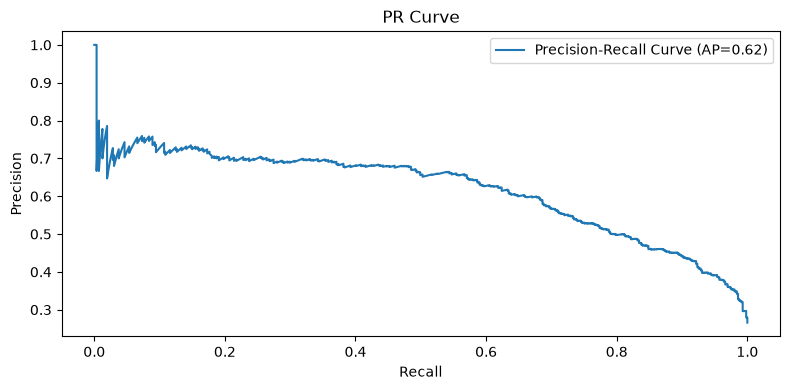

In [75]:
plt.figure(figsize=(8, 4))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP={np.round(average_precision_score(y_test, proba), 2)})')
plt.title('PR Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.savefig("../figures/Sprint12/pr_curve.png", dpi=300)
plt.show()

In [82]:
# best possible threshold
FINAL_THRESHOLD = 0.40

In [79]:
# Inference
new_customer = pd.DataFrame({
    "gender": ["Female"],
    "SeniorCitizen": [0],
    "Partner": ["No"],
    "Dependents": ["No"],
    "tenure": [3],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [92.5],
    "TotalCharges": [277.5]
})

In [80]:
probability = model.predict_proba(new_customer)[0, 1]

In [83]:
prediction = int(probability >= FINAL_THRESHOLD)

In [87]:
print(f'Customer Churn Probability : {probability*100:.2f}%')
print(f'Selected Threshold : {FINAL_THRESHOLD:.2f}')
print(f'Final Prediction : {'Churn' if prediction == 1 else 'Not Churn'}')

Customer Churn Probability : 75.98%
Selected Threshold : 0.40
Final Prediction : Churn


## Engineering Analysis

During this sprint, the classification threshold was optimized to improve the business value of the churn prediction model rather than relying on the default threshold of 0.5. Multiple threshold values were evaluated using Accuracy, Precision, Recall, and F1-score, alongside ROC and Precision–Recall curves.

The analysis showed that a threshold of 0.40 provided the most appropriate balance between Precision and Recall for the customer churn problem. Since the primary business objective is to identify as many customers at risk of churn as possible, increasing Recall was considered more valuable than maximizing Precision.

Additionally, the deployment workflow was validated by loading the previously saved pipeline, performing inference on unseen customer data, and generating predictions using the optimized threshold. This demonstrates that the trained model can be reused in a production environment without retraining.

## Key Findings

- The default classification threshold (0.50) was not optimal for the churn prediction objective.
- Threshold optimization showed that 0.40 achieved the best trade-off between Recall and Precision.
- Lowering the threshold increased Recall while introducing an acceptable reduction in Precision, which aligns with the business objective of minimizing False Negatives.
- ROC and Precision–Recall curves confirmed that the selected threshold provides a reasonable operating point for the classifier.
- The saved pipeline successfully handled preprocessing and prediction, demonstrating that the model is deployment-ready.
- Inference on new customer samples verified that the complete prediction workflow operates correctly using the optimized threshold.

## Sprint Retrospective

This sprint focused on bridging the gap between model development and production readiness. Rather than improving the classifier itself, the emphasis shifted toward optimizing decision-making through threshold selection and validating the deployment pipeline.

One important lesson learned was that classification performance is not determined solely by the model, but also by the decision threshold. Selecting an appropriate threshold can significantly improve business outcomes without retraining the model.

Another valuable outcome was understanding the distinction between probability estimation (predict_proba) and final classification decisions. This concept is essential for deploying machine learning models in real-world applications where business requirements may change over time.

Finally, loading the saved pipeline and performing inference on new customer records confirmed that the project is now ready to transition into API deployment using FastAPI in the next sprint.

In [88]:
# Production Configuration
FINAL_THRESHOLD = 0.40

joblib.dump(model, "../models/logistic_regression_pipeline.joblib")

['../models/logistic_regression_pipeline.joblib']